In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("работает")

работает


In [12]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
df.shape

(891, 15)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [15]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

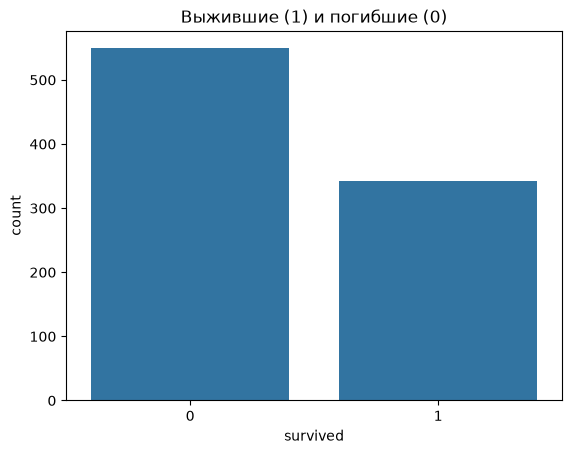

In [17]:
sns.countplot(data=df, x="survived")
plt.title("Выжившие (1) и погибшие (0)")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

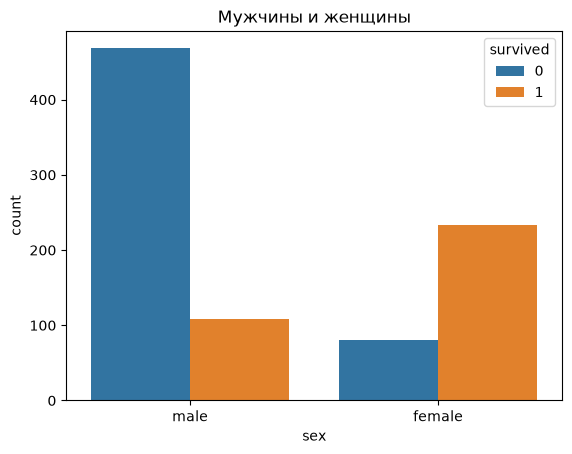

In [18]:
sns.countplot(data=df, x='sex', hue='survived')
plt.title('Мужчины и женщины')
plt.show

In [19]:
df.groupby('sex')['survived'].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [20]:
df["age"].mean()            # средний возраст
df["sex"].value_counts()    # сколько мужчин / женщин
df["pclass"].value_counts() # сколько в каждом классе
df.groupby("sex")["survived"].mean()  # доля выживших по полу

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

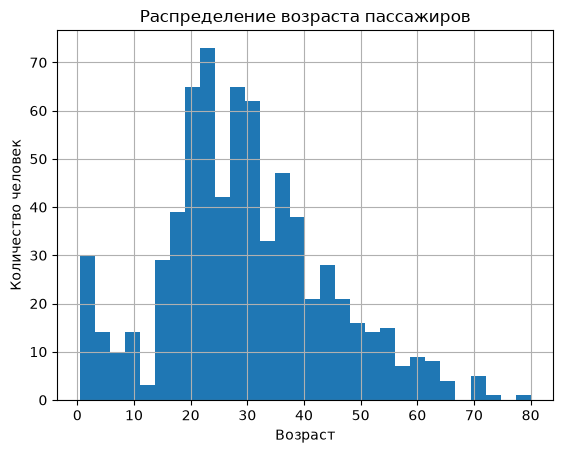

In [25]:
df['age'].hist(bins=30)
plt.title('Распределение возраста пассажиров')
plt.xlabel('Возраст')
plt.ylabel('Количество человек')
plt.show()

In [26]:
df['age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

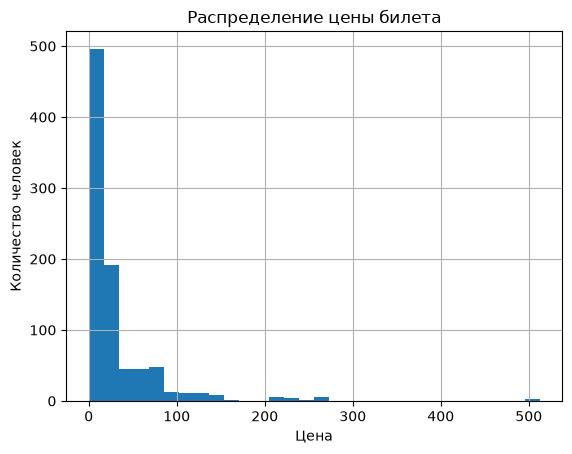

In [28]:
df['fare'].hist(bins=30)
plt.title('Распределение цены билета')
plt.xlabel('Цена')
plt.ylabel('Количество человек')
plt.show()

In [30]:
df['fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

In [33]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [34]:
df.groupby('sex')['survived'].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [35]:
df.groupby('pclass')['survived'].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [36]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [38]:
df.groupby('survived')['age'].mean()

survived
0    30.626179
1    28.343690
Name: age, dtype: float64

In [39]:
df.groupby('survived')['fare'].mean()

survived
0    22.117887
1    48.395408
Name: fare, dtype: float64

In [41]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols].corr()

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


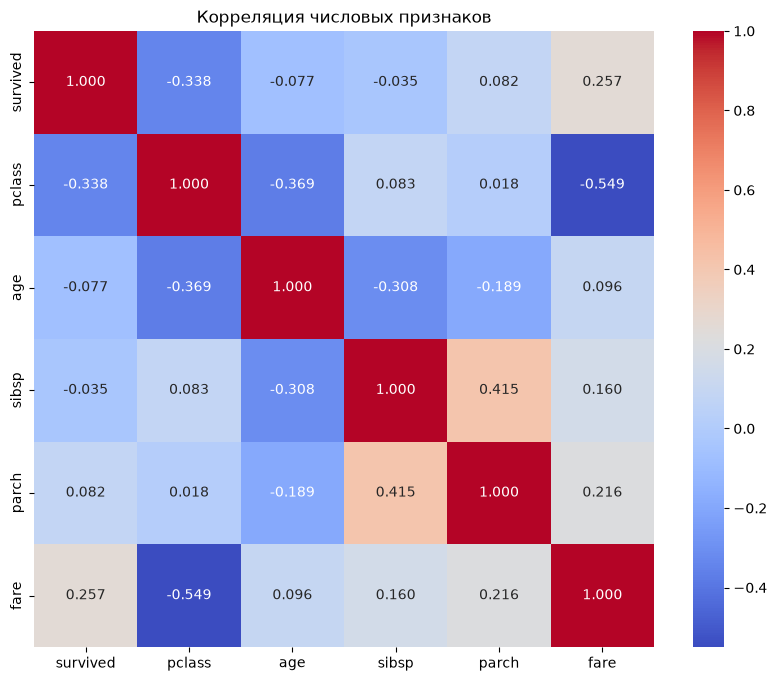

In [45]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Корреляция числовых признаков')
plt.show()

In [46]:
df['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

## Выводы Дня 2

| Признак | Тип | Связь с survived | Решение |
|---|---|---|---|
| sex | категориальный | очень сильная (74% vs 19%) | обязательно, one-hot |
| pclass | категориальный | сильная (63/47/24%) | обязательно, one-hot |
| fare | числовой, скошен | средняя (+0.26) | в модель |
| age | числовой, скошен, пропуски | слабая | в модель, медиана |
| sibsp, parch | числовые, дискретные | очень слабая | попробовать |
| embarked | категориальный, 2 пропуска | слабая-средняя | в модель, мода |
| deck | категориальный, 688 пропусков | — | удалить |x